In [1]:
import numpy as np
import matplotlib.pyplot as plt

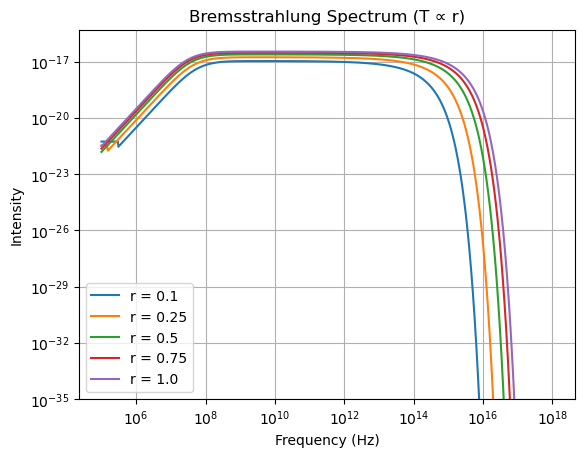

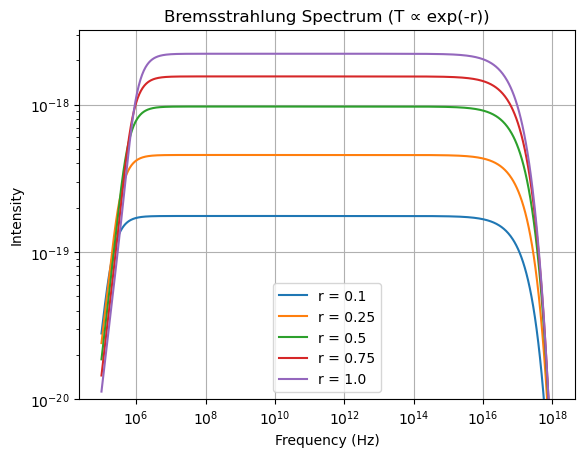

In [13]:
## CONSTANTS (cgs)
h = 6.626e-27
k = 1.38e-16
c = 3e10

## PARAMETERS   
ne = 1e12
g_ff = 1.0

## TEMPERATURE PROFILE FUNCTIONS
def temp_pr1(r, r0 = 1):
    return 1e5 * (r/r0)

def temp_pr2(r, r0 = 1):
    return 1e7 * np.exp(-r/r0)

## ABSORPTION AND EMISSION COEFFICIENTS
def j_nu(ne, nu, T):
    return 6.8e-38 * ne**2 * T**(-0.5) * np.exp(-h*nu/(k*T)) * g_ff / 4 / np.pi

def alpha_nu(ne, nu, T):
    x = h*nu/(k*T)
    fac = (1 - np.exp(-x))
    return 3.7e8 * ne**2 * T**(-0.5) * nu**(-3) * fac

## ARRAYS AND STORAGES
r = np.linspace(1e-5, 1, 100000)
dr = r[1] - r[0]
nu = np.logspace(5, 18, 800)

## SOLVE FULL RADIATIVE TRANSFER EQUATION
def solve_RT(temp_func):
    
    I = np.zeros((len(r), len(nu)))
    
    for i in range(1, len(r)):
        
        T = temp_func(r[i])
        
        j = j_nu(ne, nu, T)
        alpha = alpha_nu(ne, nu, T)
        
        ## dI/dr = j - alpha * I
        I[i] = I[i-1] + (j - alpha * I[i-1]) * dr
        
        ## numerical floor
        I[i] = np.maximum(I[i], 1e-40)
    
    return I

## COMPUTE INTENSITIES
I1 = solve_RT(temp_pr1)
I2 = solve_RT(temp_pr2)

## REQUIRED RADII
r_vals = [0.1, 0.25, 0.5, 0.75, 1.0]
indices = [np.argmin(np.abs(r - rv)) for rv in r_vals]

## PLOT FOR T ∝ r
plt.figure()

for i, rv in zip(indices, r_vals):
    plt.loglog(nu, I1[i], label=f"r = {rv}")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Intensity")
plt.title("Bremsstrahlung Spectrum (T ∝ r)")
plt.legend()
plt.ylim(1e-35)
plt.grid()
plt.show()

## PLOT FOR T ∝ exp(-r)
plt.figure()

for i, rv in zip(indices, r_vals):
    plt.loglog(nu, I2[i], label=f"r = {rv}")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Intensity")
plt.title("Bremsstrahlung Spectrum (T ∝ exp(-r))")
plt.legend()
plt.ylim(1e-20)
plt.grid()
plt.show()